In [1]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.59 🚀 Python-3.10.16 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24253MiB)
Setup complete ✅ (40 CPUs, 110.0 GB RAM, 145.9/219.0 GB disk)


In [2]:
!yolo task=detect mode=predict model=yolo11n.pt conf=0.25 source='park.jpg' save=True


Ultralytics 8.3.59 🚀 Python-3.10.16 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24253MiB)
YOLO11n summary (fused): 238 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

image 1/1 /home/xr/dl/05-目标检测/park.jpg: 416x640 5 persons, 5 dogs, 78.5ms
Speed: 3.9ms preprocess, 78.5ms inference, 131.2ms postprocess per image at shape (1, 3, 416, 640)
Results saved to runs/detect/predict4
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [3]:
# 检测结果保存在 ./runs/detect/predict/park.jpg

In [4]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open('park.jpg')
result = model.predict(image, conf=0.25)[0]


0: 416x640 5 persons, 5 dogs, 87.6ms
Speed: 5.0ms preprocess, 87.6ms inference, 126.7ms postprocess per image at shape (1, 3, 416, 640)


In [5]:
result.boxes.xyxy

tensor([[1483.6847,  223.2529, 1671.5717,  653.0790],
        [ 784.4540,  730.4044, 1126.3210, 1099.9285],
        [ 110.6620,  451.1227,  265.0275,  990.2900],
        [ 478.0207,  898.7127,  631.9283, 1048.0483],
        [ 303.8425,  720.1336,  515.5456,  952.7198],
        [1443.3220,  656.0519, 1752.4034,  922.8633],
        [ 635.4854,  530.9858,  787.6328,  778.5215],
        [1008.7125,  578.8773, 1085.1228,  743.9899],
        [1047.1962,  500.6496, 1116.6917,  645.2845],
        [1446.6791,  722.1611, 1727.8953,  920.9157]], device='cuda:0')

In [6]:
result.boxes.conf

tensor([0.9078, 0.9000, 0.8892, 0.8798, 0.8231, 0.8198, 0.7955, 0.6890, 0.6034, 0.5805], device='cuda:0')

In [7]:
result.boxes.cls

tensor([ 0., 16.,  0., 16., 16., 16.,  0.,  0.,  0., 16.], device='cuda:0')

In [8]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

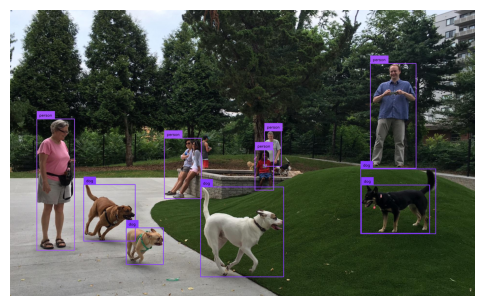

In [9]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(6, 6))

In [10]:
### Fine-tune YOLO11 on custom dataset

In [1]:
import os
HOME=os.getcwd()
print(HOME)

/home/xr/dl/05-目标检测


In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="Uh1dAuHWkCsAsuk815Lg")

workspace = rf.workspace("liangdianzhong")
project = workspace.project("-qvdww")
version = project.version(3)
dataset = version.download("yolov11",location="../datasets/qvdww",overwrite=False)

loading Roboflow workspace...
loading Roboflow project...


In [5]:
%cd {HOME}/../datasets/qvdww

/home/xr/dl/datasets/qvdww


This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.


In [6]:
!yolo task=detect mode=train model=yolo11s.pt data=data.yaml epochs=10 imgsz=640 plots=True


Ultralytics 8.3.59 🚀 Python-3.10.16 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24253MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=T

In [7]:
HOME=os.getcwd()
print(HOME)

/home/xr/dl/datasets/qvdww


In [8]:
!ls {HOME}/runs/detect/train/

F1_curve.png					results.png
PR_curve.png					train_batch0.jpg
P_curve.png					train_batch1.jpg
R_curve.png					train_batch2.jpg
args.yaml					val_batch0_labels.jpg
confusion_matrix.png				val_batch0_pred.jpg
confusion_matrix_normalized.png			val_batch1_labels.jpg
events.out.tfevents.1736747557.501-2.2104608.0	val_batch1_pred.jpg
labels.jpg					val_batch2_labels.jpg
labels_correlogram.jpg				val_batch2_pred.jpg
results.csv					weights


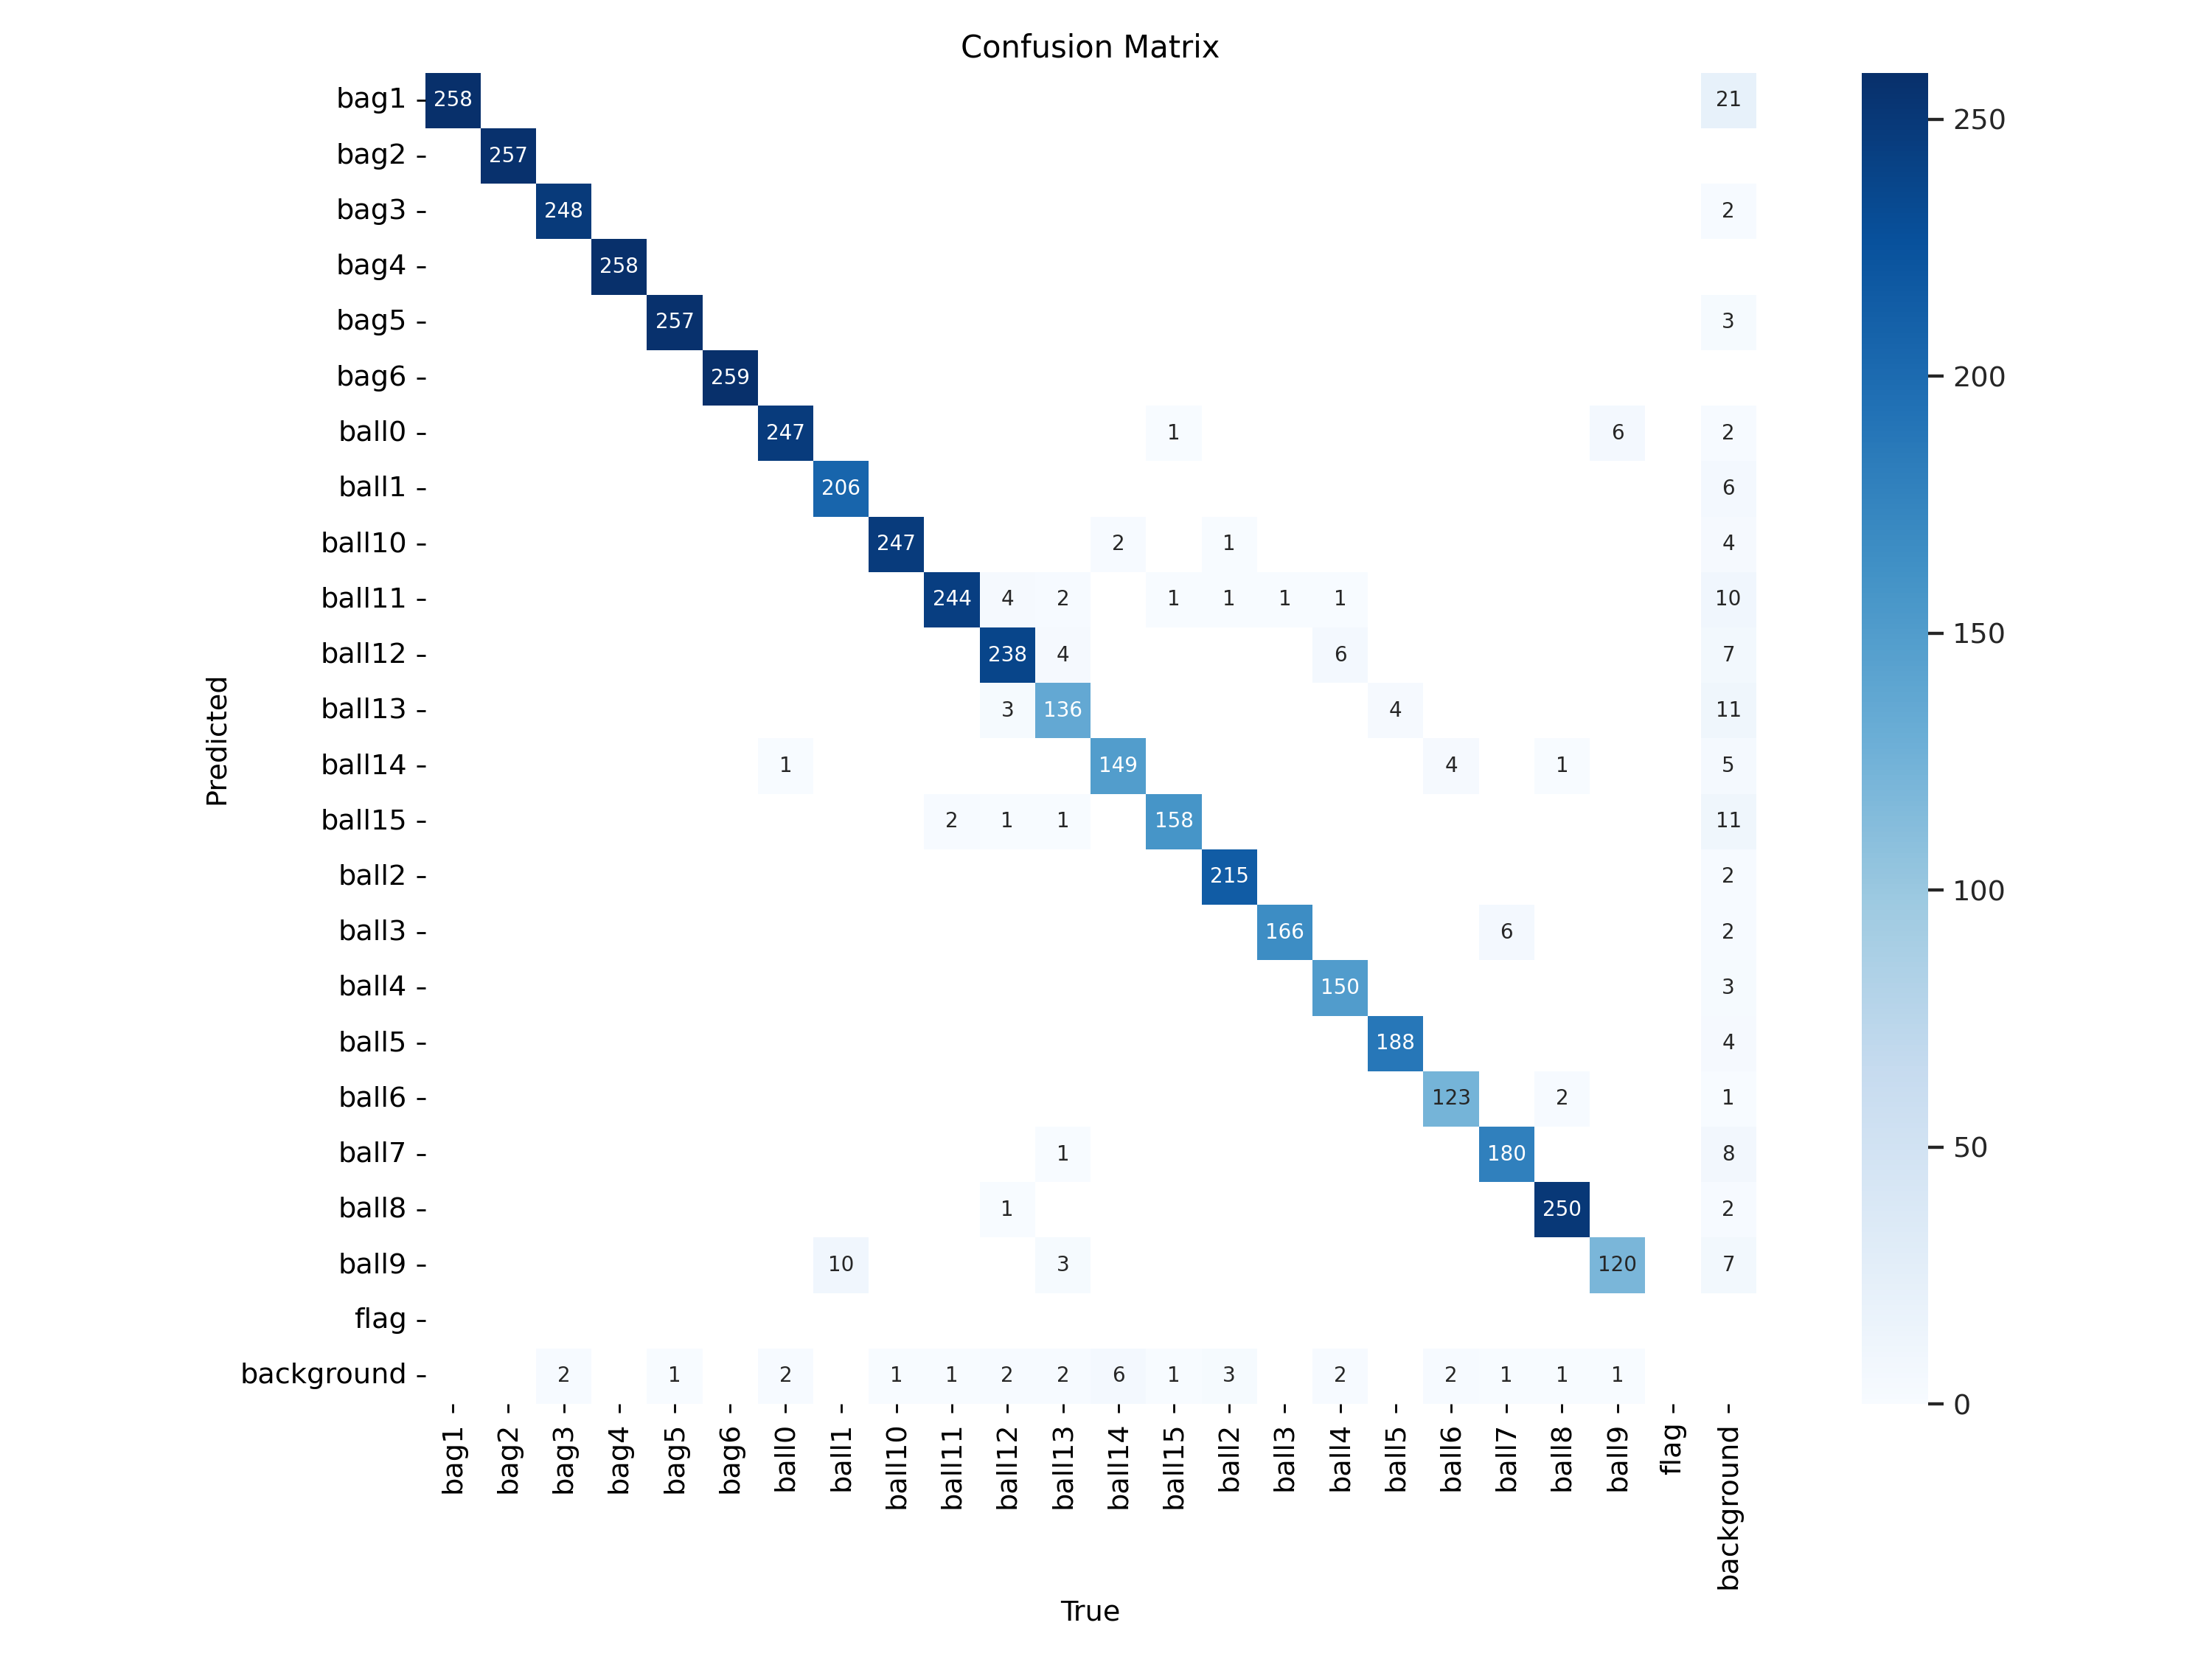

In [9]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

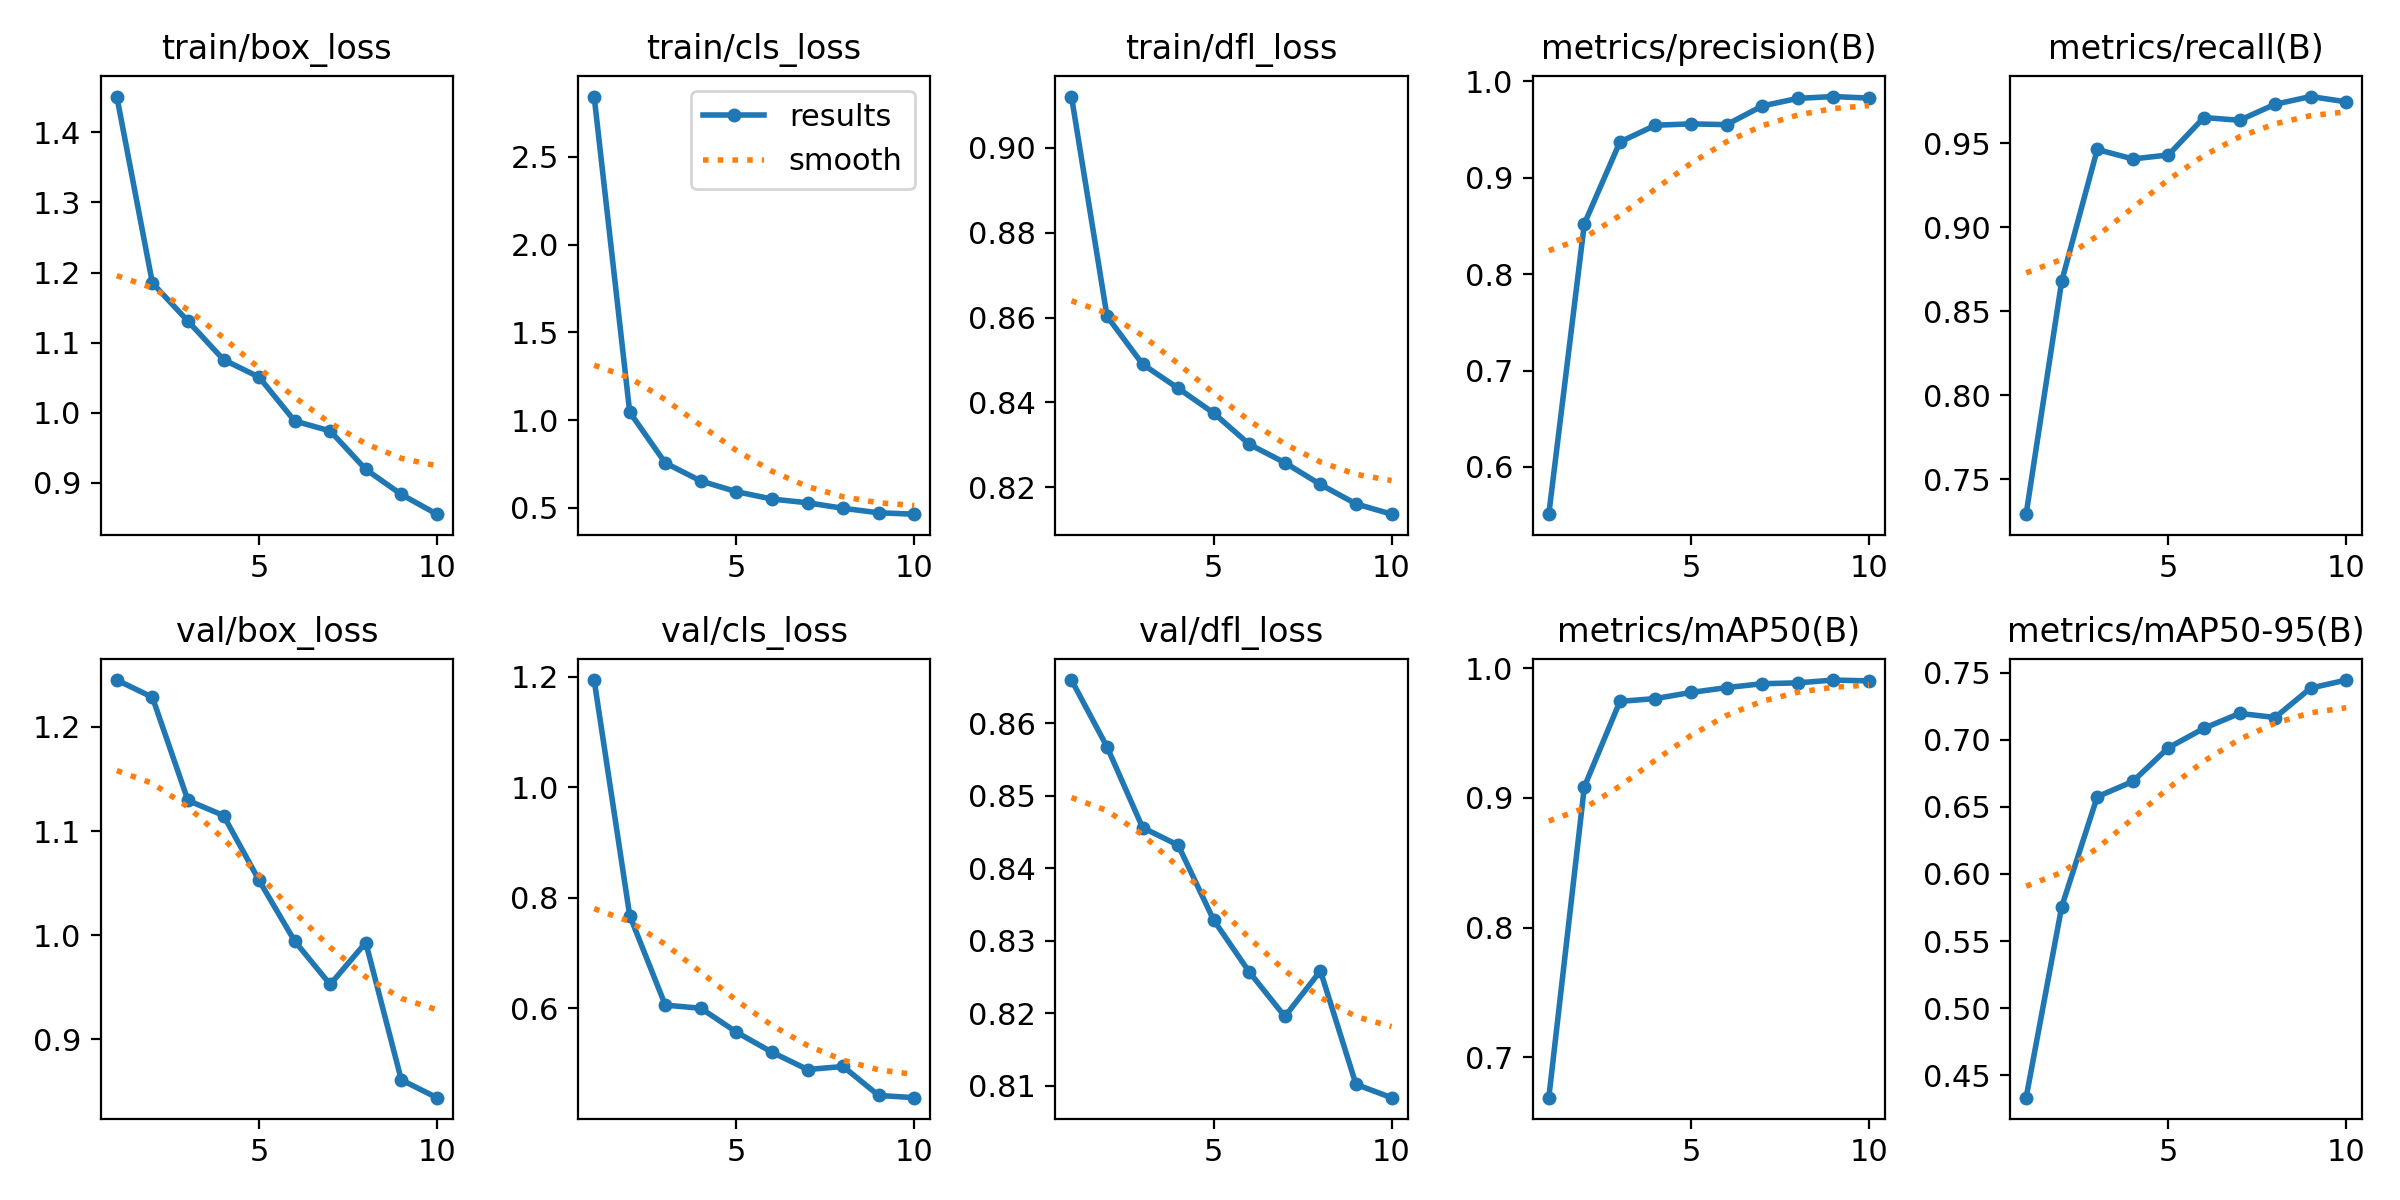

In [10]:
IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

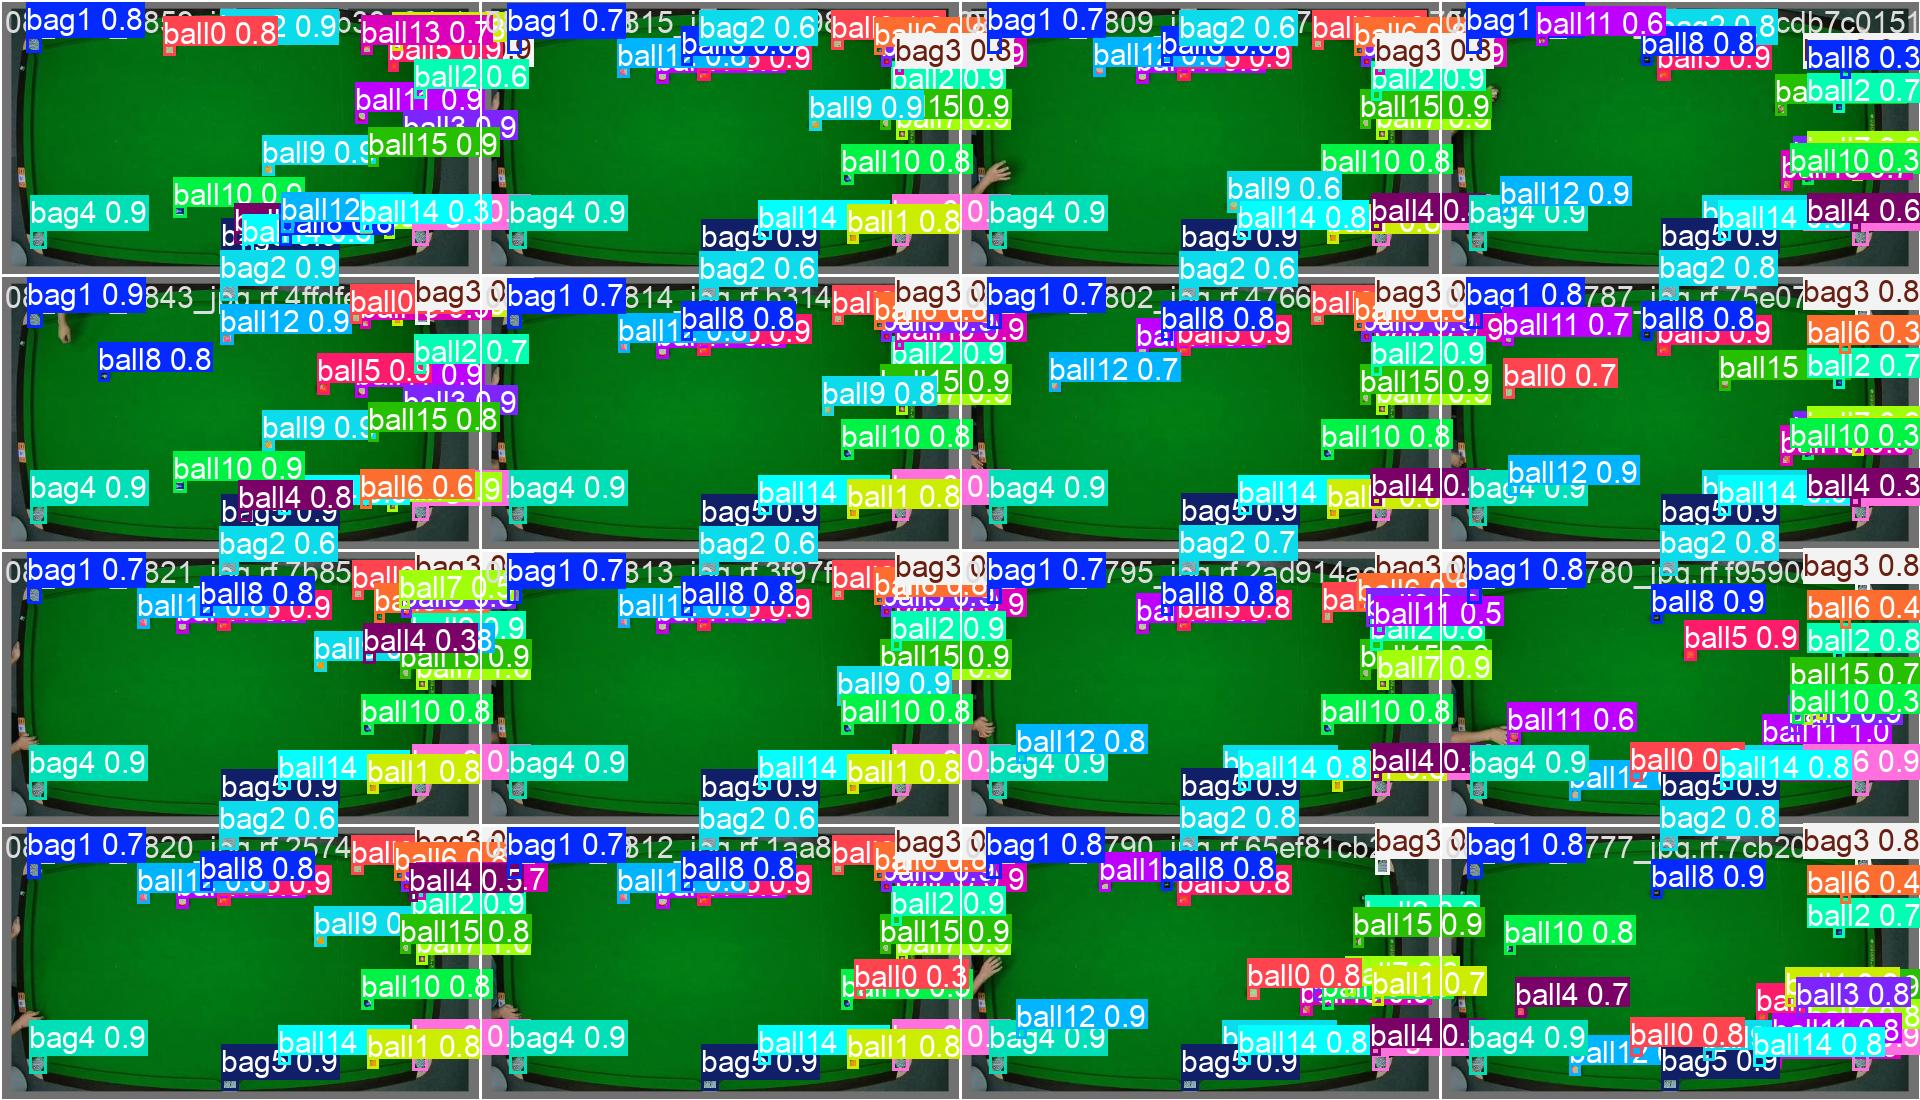

In [11]:
IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [12]:
### Validate fine-tuned model

In [13]:
!yolo task=detect mode=val model=./runs/detect/train/weights/best.pt data=./data.yaml

Ultralytics 8.3.59 🚀 Python-3.10.16 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24253MiB)
YOLO11s summary (fused): 238 layers, 9,421,701 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /home/xr/dl/datasets/qvdww/valid/labels.cache... 259 images, 0 bac
val: WARNING ⚠️ /home/xr/dl/datasets/qvdww/valid/images/08_21C_0250_jpg.rf.b164fca68a7a644a126019aa776912c1.jpg: 2 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  m
                   all        259       4652      0.982      0.975       0.99      0.745
                  bag1        258        258      0.975          1      0.995      0.746
                  bag2        257        257      0.999          1      0.995      0.905
                  bag3        250        250          1      0.991      0.995      0.824
                  bag4        258        258      0.998          1      0.995      0.763
                  bag5        258        258      0.994      0.996      

In [ ]:
### Inference with custom model


In [14]:
!yolo task=detect mode=predict model=./runs/detect/train/weights/best.pt conf=0.25 source=./test/images save=True


Ultralytics 8.3.59 🚀 Python-3.10.16 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24253MiB)
YOLO11s summary (fused): 238 layers, 9,421,701 parameters, 0 gradients, 21.3 GFLOPs

image 1/130 /home/xr/dl/datasets/qvdww/test/images/08_21A_0007_jpg.rf.9e8959e1a1730f1c5c940d000b3d416c.jpg: 384x640 1 bag1, 1 bag2, 1 bag3, 1 bag4, 1 bag5, 1 bag6, 1 ball10, 2 ball12s, 1 ball2, 1 ball5, 1 ball8, 86.9ms
image 2/130 /home/xr/dl/datasets/qvdww/test/images/08_21A_0008_jpg.rf.2dd16a0099bef3498fc559918545a9bd.jpg: 384x640 1 bag1, 1 bag2, 1 bag3, 1 bag4, 1 bag5, 1 bag6, 1 ball0, 1 ball10, 1 ball12, 1 ball13, 1 ball2, 1 ball5, 1 ball8, 12.8ms
image 3/130 /home/xr/dl/datasets/qvdww/test/images/08_21A_0022_jpg.rf.fe9e24fff670ceb0338b20bd49351eda.jpg: 384x640 1 bag1, 1 bag2, 1 bag3, 1 bag4, 1 bag5, 1 bag6, 1 ball0, 1 ball10, 1 ball12, 1 ball2, 1 ball5, 1 ball8, 12.1ms
image 4/130 /home/xr/dl/datasets/qvdww/test/images/08_21A_0088_jpg.rf.822feee76db82a3f805ca5dfd2a4f19c.jpg: 384x640 1 bag1, 1 bag2, 1 b

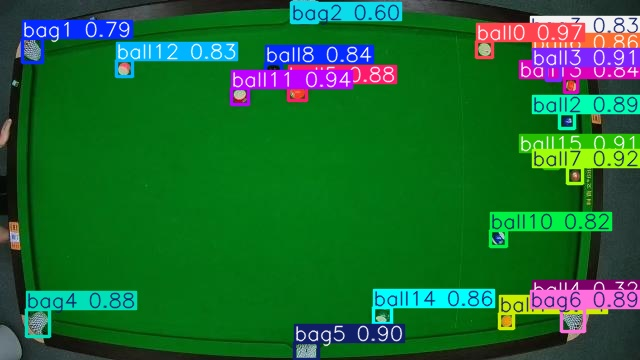

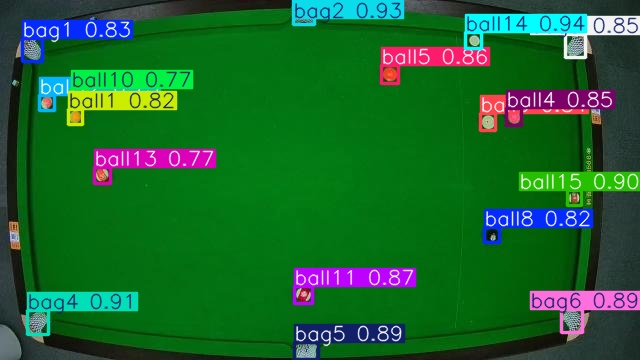

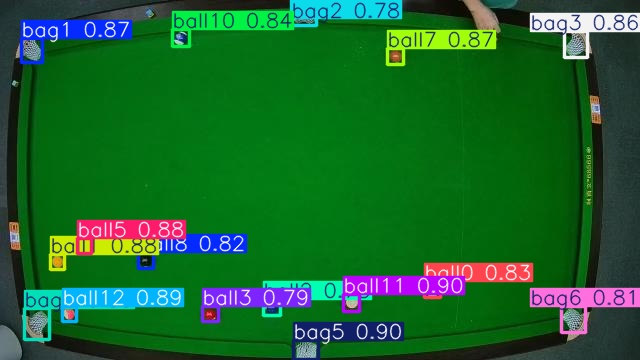

In [15]:
import glob
latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")